<a href="https://colab.research.google.com/github/1999fello-del/steam-data-analysis-ml/blob/main/notebooks/notebook_limpieza_steam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

#.- Cargamos el archivo CSV
df = pd.read_csv('/content/drive/MyDrive/Mio/PORFOLIO/1. Steam/games_march2025_full.csv')

#.- Aplicar comando Head para ver primeras filas
print(f"Forma original: {df.shape}")
df.head()

Forma original: (94948, 47)


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [2]:
# 7.- Prescindir de las columnas con muchos valores nulos o irrelevantes
cols_drop = [
    'detailed_description', 'about_the_game', 'short_description', 'reviews',
    'header_image', 'website', 'support_url', 'support_email', 'metacritic_url',
    'notes', 'supported_languages', 'full_audio_languages', 'packages',
    'screenshots', 'movies', 'tags', 'score_rank'
]

df = df.drop(columns=cols_drop)

# 8, 9 y 10.- Convertimos a formato fecha y filtramos (lanzamientos desde 2020)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df[df['release_date'] >= '2020-01-01']

# 11 y 12.- Revisamos nulos y estadísticas
print("Valores nulos por columna:")
print(df.isnull().sum())
df[['price','positive','negative','num_reviews_total','average_playtime_forever']].describe()

Valores nulos por columna:
appid                       0
name                        0
release_date                0
required_age                0
price                       0
dlc_count                   0
windows                     0
mac                         0
linux                       0
metacritic_score            0
achievements                0
recommendations             0
developers                  0
publishers                  0
categories                  0
genres                      0
user_score                  0
positive                    0
negative                    0
estimated_owners            0
average_playtime_forever    0
average_playtime_2weeks     0
median_playtime_forever     0
median_playtime_2weeks      0
discount                    0
peak_ccu                    0
pct_pos_total               0
num_reviews_total           0
pct_pos_recent              0
num_reviews_recent          0
dtype: int64


,price,positive,negative,num_reviews_total,average_playtime_forever
count,65847.000000,6.584700e+04,65847.000000,65847.000000,65847.000000
mean,6.815871,6.035668e+02,107.731970,897.490865,42.085744
std,13.718870,1.105969e+04,2493.249085,11818.318417,720.844420
min,0.000000,0.000000e+00,0.000000,-1.000000,0.000000
25%,0.990000,0.000000e+00,0.000000,-1.000000,0.000000
50%,3.990000,3.000000e+00,1.000000,11.000000,0.000000
75%,9.590000,2.200000e+01,5.000000,51.000000,0.000000
max,999.980000,1.098373e+06,322363.000000,983230.000000,82588.000000


In [3]:
# 13 a 16.- Limpieza de datos falsos y outliers
df = df[df['num_reviews_total'] >= 0]
df = df[df['pct_pos_total'] >= 0]
df = df[df['price'] <= 200]
df = df[df['average_playtime_forever'] <= 5000]
df = df[df['num_reviews_total'] <= 200000]

# 18.- Guardar csv intermedio
df.to_csv("steam_cleaned.csv", index=False)
print(f"Forma después de limpieza: {df.shape}")
df[['price','num_reviews_total','average_playtime_forever']].describe()

Forma después de limpieza: (34468, 30)


,price,num_reviews_total,average_playtime_forever
count,34468.000000,34468.000000,34468.000000
mean,7.622550,1269.648602,46.666386
std,12.415537,7470.107996,276.970668
min,0.000000,10.000000,0.000000
25%,0.000000,19.000000,0.000000
50%,3.990000,45.000000,0.000000
75%,9.990000,190.000000,0.000000
max,199.990000,197632.000000,4853.000000


In [4]:
# 19.- Diferenciar juegos gratis VS de pago
df['game_type'] = df['price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

# 20.- Ratio de aceptacion (añadimos una pequeña corrección para evitar división por cero)
df['review_score'] = df['positive'] / (df['positive'] + df['negative']).replace(0, np.nan)
df['review_score'] = df['review_score'].fillna(0)

# 21.- Guardar archivo final
df.to_csv("steam_games_clean_final.csv", index=False)
print("Archivo 'steam_games_clean_final.csv' creado con éxito.")

Archivo 'steam_games_clean_final.csv' creado con éxito.


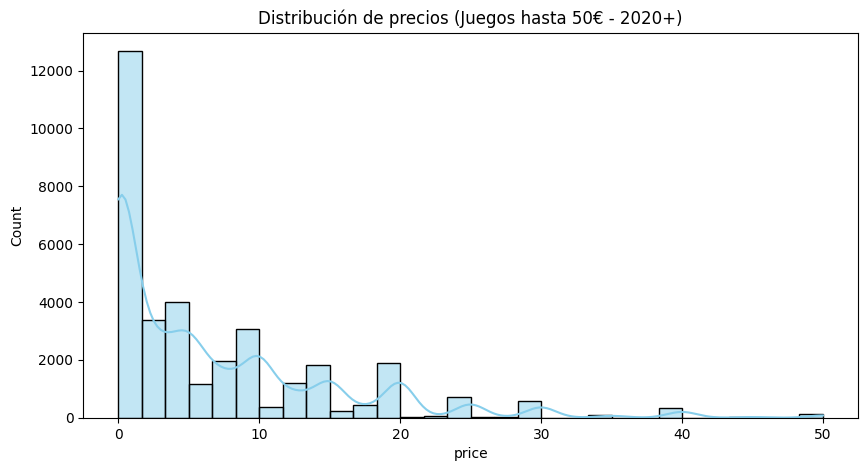

/tmp/ipykernel_4887/3518042788.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='game_type', data=df, palette='viridis')


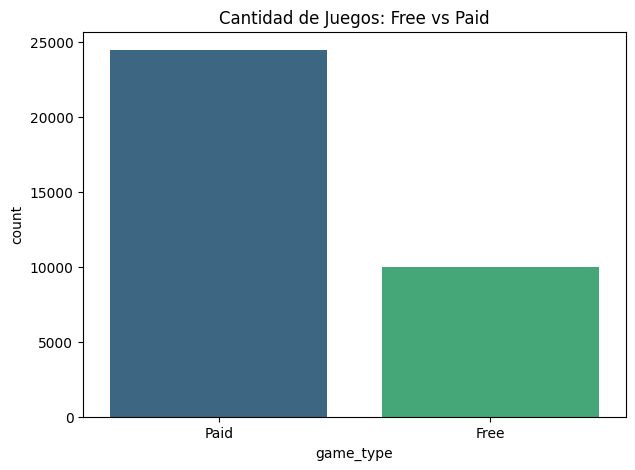

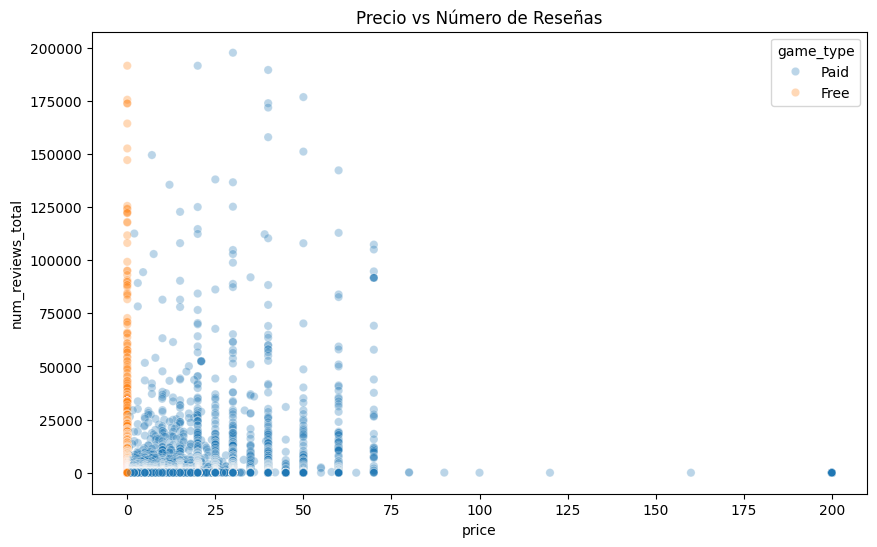

In [5]:
# 22.- Distribución de precios
plt.figure(figsize=(10,5))
sns.histplot(df[df['price'] <= 50]['price'], bins=30, kde=True, color='skyblue')
plt.title("Distribución de precios (Juegos hasta 50€ - 2020+)")
plt.show()

# 23.- Juegos gratis vs De pago
plt.figure(figsize=(7,5))
sns.countplot(x='game_type', data=df, palette='viridis')
plt.title("Cantidad de Juegos: Free vs Paid")
plt.show()

# 24.- Precio vs Número de reviews
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price', y='num_reviews_total', alpha=0.3, hue='game_type')
plt.title("Precio vs Número de Reseñas")
plt.show()

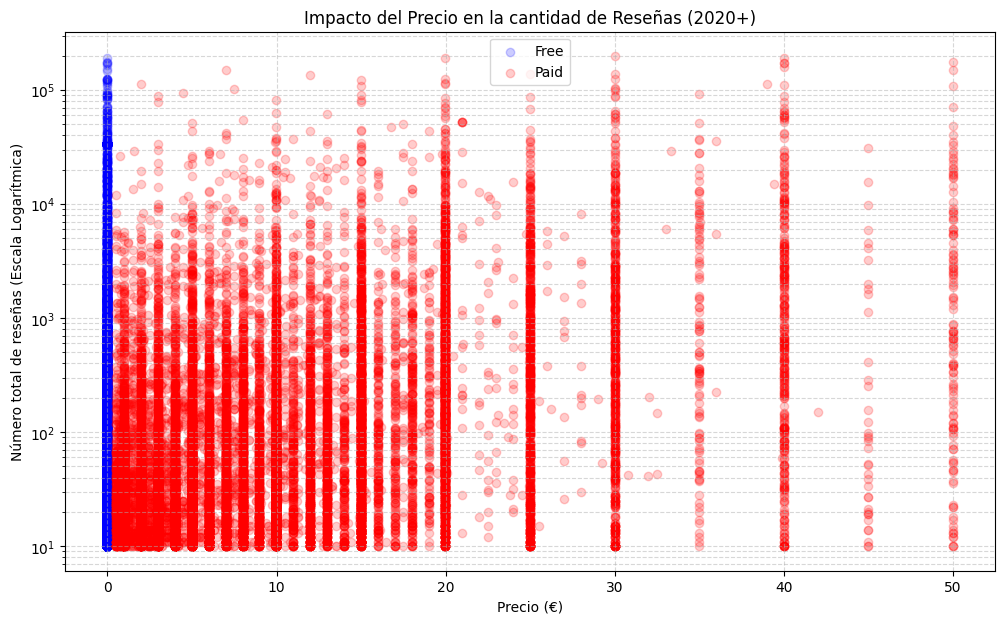

Conteo final por tipo:
game_type
Paid    24481
Free     9987
Name: count, dtype: int64


In [6]:
# 32 a 34.- Gráfico comparativo con escala logarítmica
plt.figure(figsize=(12,7))

df_free = df[df['price'] == 0]
df_paid = df[(df['price'] > 0) & (df['price'] <= 50)]

plt.scatter(df_free['price'], df_free['num_reviews_total'], color='blue', alpha=0.2, label='Free')
plt.scatter(df_paid['price'], df_paid['num_reviews_total'], color='red', alpha=0.2, label='Paid')

plt.yscale('log')
plt.xlabel('Precio (€)')
plt.ylabel('Número total de reseñas (Escala Logarítmica)')
plt.title('Impacto del Precio en la cantidad de Reseñas (2020+)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Resumen final de conteos
print("Conteo final por tipo:")
print(df['game_type'].value_counts())